# Daily Challenge: Stock Price Prediction with LSTM (PyTorch)

Week 11, Day 2

**Goal:** predict the **next day's closing price** of a stock from the previous 30 trading days, with an LSTM built in PyTorch, and evaluate it with the R² score.

**Dataset:** [Stock Market Dataset (Kaggle, jacksoncrow)](https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset): daily prices of all NASDAQ-traded stocks and ETFs (`stocks/` and `etfs/` folders, one CSV per symbol) and the `symbols_valid_meta.csv` file describing each symbol. We use **Apple (AAPL)**, which has the longest history (1980–2020).

## 1. Install Required Libraries

`torch`, `scikit-learn`, `pandas` and `matplotlib` are already installed in Colab. We only need `kagglehub` to download the stock file from Kaggle. (`gensim` and `spacy`, listed in the instructions, are NLP libraries and are not needed for this time-series task.)

In [1]:
!pip install -q kagglehub

In [2]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import kagglehub

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

PyTorch: 2.14.1+cpu | device: cpu


## 2. Load and Preprocess the Dataset

In [3]:
# Metadata of all the symbols (the provided symbols_valid_meta.csv file)
meta_path = "data/symbols_valid_meta.csv"
if not os.path.exists(meta_path):
    meta_path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset", path="symbols_valid_meta.csv")
meta = pd.read_csv(meta_path)
print(meta.shape)
print("ETF vs stocks:", meta['ETF'].value_counts().to_dict())
display(meta[meta['Symbol'] == 'AAPL'])

(8049, 12)
ETF vs stocks: {'N': 5884, 'Y': 2165}


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
12,Y,AAPL,Apple Inc. - Common Stock,Q,Q,N,100.0,N,N,NaN,AAPL,N


In [4]:
SYMBOL = "AAPL"
# Download only this stock's file (~250 KB) instead of the whole 2.7 GB dataset
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset", path=f"stocks/{SYMBOL}.csv")
df = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")
print(df.shape, "| from", df.index.min().date(), "to", df.index.max().date())
print("Missing values:", df.isna().sum().sum())
display(df.head())
display(df.tail())

(9909, 6) | from 1980-12-12 to 2020-04-01
Missing values: 0


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800
2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200
2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100
2020-03-31,255.600006,262.489990,252.000000,254.289993,254.289993,49250500
2020-04-01,246.500000,248.720001,239.130005,240.910004,240.910004,43956200


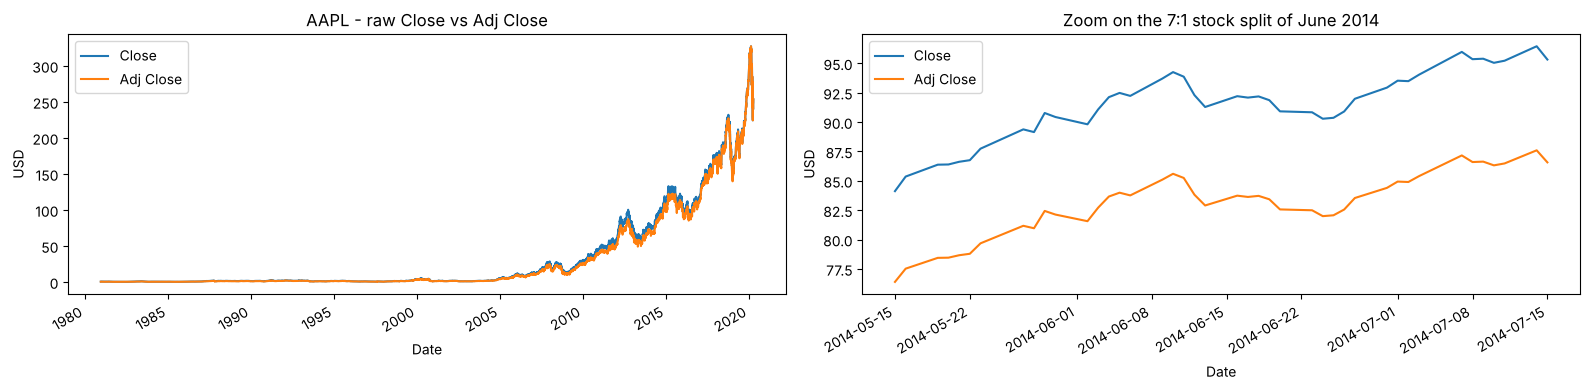

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df[['Close', 'Adj Close']].plot(ax=axes[0], title=f'{SYMBOL} - raw Close vs Adj Close')
df.loc['2014-05-15':'2014-07-15', ['Close', 'Adj Close']].plot(ax=axes[1], title='Zoom on the 7:1 stock split of June 2014')
for ax in axes: ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

**Why we use adjusted prices:** the raw `Close` column is not adjusted for **stock splits**. In June 2014 Apple split its shares 7-for-1, so the raw price drops from about \$650 to \$92 overnight, although nothing happened to the company's value (the same happens at every split). A model trained on raw prices would learn these artificial crashes. The `Adj Close` column corrects all past prices for splits and dividends, so we use it as the closing price, and we adjust `Open`, `High` and `Low` with the same ratio.

**Preprocessing:**
- drop the unnecessary columns (`Adj Close` once used, and the raw unadjusted prices);
- create the **target**: the next day's closing price (`Close` shifted by −1 day); the last row has no target and is removed.

In [6]:
ratio = df['Adj Close'] / df['Close']
data = pd.DataFrame({
    'Open': df['Open'] * ratio,
    'High': df['High'] * ratio,
    'Low': df['Low'] * ratio,
    'Close': df['Adj Close'],
    'Volume': df['Volume'].astype(float),
})
data['Target'] = data['Close'].shift(-1)   # next day's closing price
data = data.dropna()
FEATURES = ['Open', 'High', 'Low', 'Close', 'Volume']
print(data.shape)
display(data.tail())

(9908, 6)


,Open,High,Low,Close,Volume,Target
Date,,,,,,
2020-03-25,250.750000,258.250000,244.300003,245.520004,75900500.0,258.440002
2020-03-26,246.520004,258.679993,246.360001,258.440002,63021800.0,247.740005
2020-03-27,252.750000,255.869995,247.050003,247.740005,51054200.0,254.809998
2020-03-30,250.740005,255.520004,249.399994,254.809998,41994100.0,254.289993
2020-03-31,255.600006,262.489990,252.000000,254.289993,49250500.0,240.910004


### Normalization with `MinMaxScaler`

A first, naive approach would be to scale the prices directly between 0 and 1. But with a chronological split, this does not work for a stock that grew a lot: the scaler is fitted on the training period only (to avoid looking into the future), and the test prices are far outside the training range.

In [7]:
n = len(data)
train_end, val_end = int(n * 0.70), int(n * 0.85)
naive_scaler = MinMaxScaler().fit(data[['Close']].iloc[:train_end])
test_scaled_naive = naive_scaler.transform(data[['Close']].iloc[val_end:])
print(f"Training period max close: {data['Close'].iloc[:train_end].max():.2f} USD")
print(f"Test period close: {data['Close'].iloc[val_end:].min():.2f} - {data['Close'].iloc[val_end:].max():.2f} USD")
print(f"Scaled test values: {test_scaled_naive.min():.1f} - {test_scaled_naive.max():.1f}  (the model only saw values between 0 and 1!)")

Training period max close: 24.78 USD
Test period close: 75.97 - 327.20 USD
Scaled test values: 3.1 - 13.3  (the model only saw values between 0 and 1!)


With raw prices, the test values are scaled to between about 3 and 13, while the network was only trained on values between 0 and 1: an LSTM cannot extrapolate that far (in our tests, this gave a negative R² on the test set).

**Solution: normalise each 30-day window relative to its last closing price.** Each input becomes "how far each day's prices were from today's close" (e.g. −2%, +1%), and the target becomes the **next-day return** (next close / today's close − 1). These relative values have the same scale in 1985 and in 2020, so the model can generalise across time. We then apply the **`MinMaxScaler`** (fitted on the training windows only) to these relative features and to the target. The predicted price is recovered as `today's close × (1 + predicted return)`.

In [8]:
WINDOW = 30

values = data[FEATURES + ['Target']].values
X_rel, y_rel, last_close, dates = [], [], [], []
for i in range(WINDOW, len(values) + 1):
    w = values[i - WINDOW:i]
    lc = w[-1, 3]                                   # last close of the window ("today")
    prices = w[:, :4] / lc - 1                      # OHLC relative to today's close
    volume = w[:, 4:5] / w[:, 4].mean()             # volume relative to the window average
    X_rel.append(np.hstack([prices, volume]))
    y_rel.append(w[-1, 5] / lc - 1)                 # next-day return
    last_close.append(lc)
    dates.append(data.index[i - 1])

X_rel, y_rel, last_close = np.array(X_rel), np.array(y_rel), np.array(last_close)
dates = pd.DatetimeIndex(dates)
print("Windows:", X_rel.shape, "(samples, days, features) | targets:", y_rel.shape)

Windows: (9879, 30, 5) (samples, days, features) | targets: (9879,)


## 3. Prepare the Dataset for Training

In [9]:
# Chronological split: 70% train / 15% validation / 15% test
N = len(X_rel)
a, b = int(N * 0.70), int(N * 0.85)
print(f"Train: {dates[0].date()} -> {dates[a - 1].date()} ({a} samples)")
print(f"Val  : {dates[a].date()} -> {dates[b - 1].date()} ({b - a} samples)")
print(f"Test : {dates[b].date()} -> {dates[-1].date()} ({N - b} samples)")

# MinMaxScaler fitted on the training set only
x_scaler = MinMaxScaler().fit(X_rel[:a].reshape(-1, X_rel.shape[2]))
y_scaler = MinMaxScaler().fit(y_rel[:a].reshape(-1, 1))

def scale_x(X):
    return x_scaler.transform(X.reshape(-1, X.shape[2])).reshape(X.shape)

X_train, X_val, X_test = scale_x(X_rel[:a]), scale_x(X_rel[a:b]), scale_x(X_rel[b:])
y_train, y_val, y_test = [y_scaler.transform(y.reshape(-1, 1)).ravel() for y in (y_rel[:a], y_rel[a:b], y_rel[b:])]
print("Scaled training features range:", X_train.min().round(3), "-", X_train.max().round(3))

Train: 1981-01-26 -> 2008-06-20 (6915 samples)
Val  : 2008-06-23 -> 2014-05-12 (1482 samples)
Test : 2014-05-13 -> 2020-03-31 (1482 samples)
Scaled training features range: 0.0 - 1.0


In [10]:
class StockDataset(Dataset):
    """PyTorch dataset of (30-day window, next-day target) pairs."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(StockDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("One batch:", xb.shape, yb.shape)

One batch: torch.Size([64, 30, 5]) torch.Size([64])


## 4. Define the LSTM Model

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)            # out: (batch, 30, hidden_size)
        last = out[:, -1, :]             # hidden state of the last day
        return self.fc(self.dropout(last)).squeeze(-1)


class GRUModel(nn.Module):
    """Same architecture with GRU layers instead of LSTM layers."""
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

lstm_model = LSTMModel().to(device)
print(lstm_model)
print("Trainable parameters:", sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))

LSTMModel(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 51521


**Architecture:** 2 stacked recurrent layers of 64 units read the 30-day window day by day; dropout (0.2) between and after them limits overfitting; a final `Linear` (dense) layer turns the last hidden state into one number, the scaled next-day return. The instructions mention both LSTM and GRU layers, so we train both versions: a **GRU** is a simplified LSTM (2 gates instead of 3, no separate cell state), with fewer parameters.

## 5. Train the Model

In [12]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total = 0.0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * len(xb)
    return total / len(loader.dataset)

def train_model(model, epochs=30, lr=1e-3, patience=6):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}
    best_val, best_state, wait = float('inf'), None, 0
    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(model, train_loader, criterion, optimizer)
        val_loss = run_epoch(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f"Epoch {epoch:2d} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")
        if val_loss < best_val:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping (no improvement for {patience} epochs)")
                break
    model.load_state_dict(best_state)  # keep the best epoch
    return history

torch.manual_seed(SEED)
lstm_model = LSTMModel().to(device)
lstm_history = train_model(lstm_model)

Epoch  1 | train loss 0.042640 | val loss 0.000738


Epoch  2 | train loss 0.004778 | val loss 0.000646


Epoch  3 | train loss 0.004230 | val loss 0.000646


Epoch  4 | train loss 0.004036 | val loss 0.000686


Epoch  5 | train loss 0.003752 | val loss 0.000690


Epoch  6 | train loss 0.003711 | val loss 0.000759


Epoch  7 | train loss 0.003577 | val loss 0.000785


Epoch  8 | train loss 0.003398 | val loss 0.001012


Epoch  9 | train loss 0.003361 | val loss 0.000730
Early stopping (no improvement for 6 epochs)


In [13]:
torch.manual_seed(SEED)
gru_model = GRUModel().to(device)
gru_history = train_model(gru_model)

Epoch  1 | train loss 0.025890 | val loss 0.000706


Epoch  2 | train loss 0.003896 | val loss 0.000675


Epoch  3 | train loss 0.003465 | val loss 0.000648


Epoch  4 | train loss 0.003252 | val loss 0.000690


Epoch  5 | train loss 0.003173 | val loss 0.000681


Epoch  6 | train loss 0.003130 | val loss 0.000674


Epoch  7 | train loss 0.002927 | val loss 0.000688


Epoch  8 | train loss 0.002880 | val loss 0.000698


Epoch  9 | train loss 0.002821 | val loss 0.000703
Early stopping (no improvement for 6 epochs)


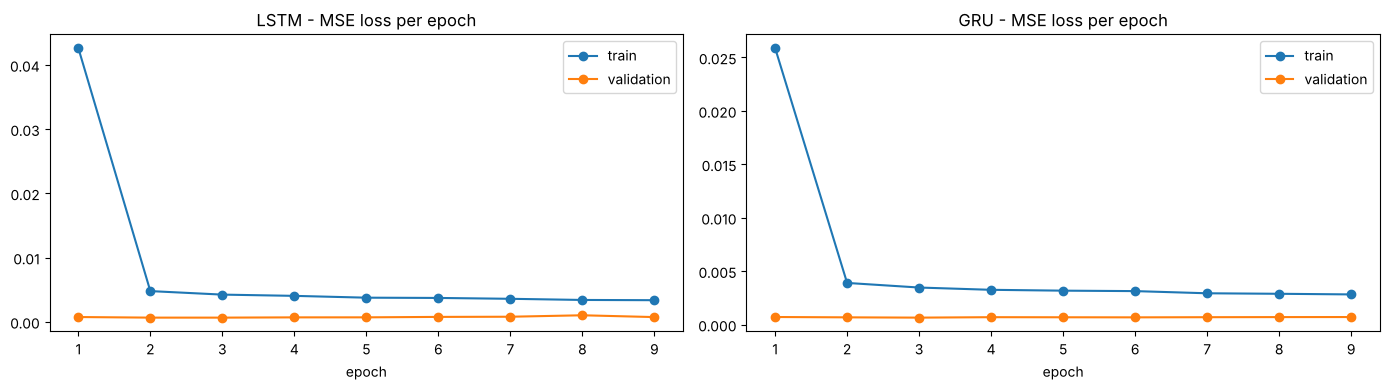

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, h) in zip(axes, [('LSTM', lstm_history), ('GRU', gru_history)]):
    ax.plot(range(1, len(h['train_loss']) + 1), h['train_loss'], 'o-', label='train')
    ax.plot(range(1, len(h['val_loss']) + 1), h['val_loss'], 'o-', label='validation')
    ax.set_title(f'{name} - MSE loss per epoch'); ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate the Model

In [15]:
def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
    return y_scaler.inverse_transform(np.concatenate(preds).reshape(-1, 1)).ravel()

true_ret = y_rel[b:]
true_price = last_close[b:] * (1 + true_ret)
naive_price = last_close[b:]                       # naive baseline: tomorrow = today

rows = {}
preds = {}
for name, model in [('LSTM', lstm_model), ('GRU', gru_model)]:
    ret = predict(model, test_loader)
    price = last_close[b:] * (1 + ret)
    preds[name] = price
    rows[name] = {'R² (price)': r2_score(true_price, price), 'MAE (USD)': mean_absolute_error(true_price, price),
                  'R² (daily return)': r2_score(true_ret, ret),
                  'direction accuracy': np.mean(np.sign(ret) == np.sign(true_ret))}
rows['Naive (tomorrow = today)'] = {'R² (price)': r2_score(true_price, naive_price),
                                    'MAE (USD)': mean_absolute_error(true_price, naive_price),
                                    'R² (daily return)': r2_score(true_ret, np.zeros_like(true_ret)),
                                    'direction accuracy': np.nan}
results = pd.DataFrame(rows).T
display(results.style.format({'R² (price)': '{:.4f}', 'MAE (USD)': '{:.3f}', 'R² (daily return)': '{:.4f}', 'direction accuracy': '{:.1%}'}))
print(f"Share of up days in the test period: {(true_ret > 0).mean():.1%}")

,R² (price),MAE (USD),R² (daily return),direction accuracy
LSTM,0.9966,1.829,0.0055,50.1%
GRU,0.9966,1.836,0.0020,50.0%
Naive (tomorrow = today),0.9966,1.832,-0.0028,nan%


Share of up days in the test period: 52.9%


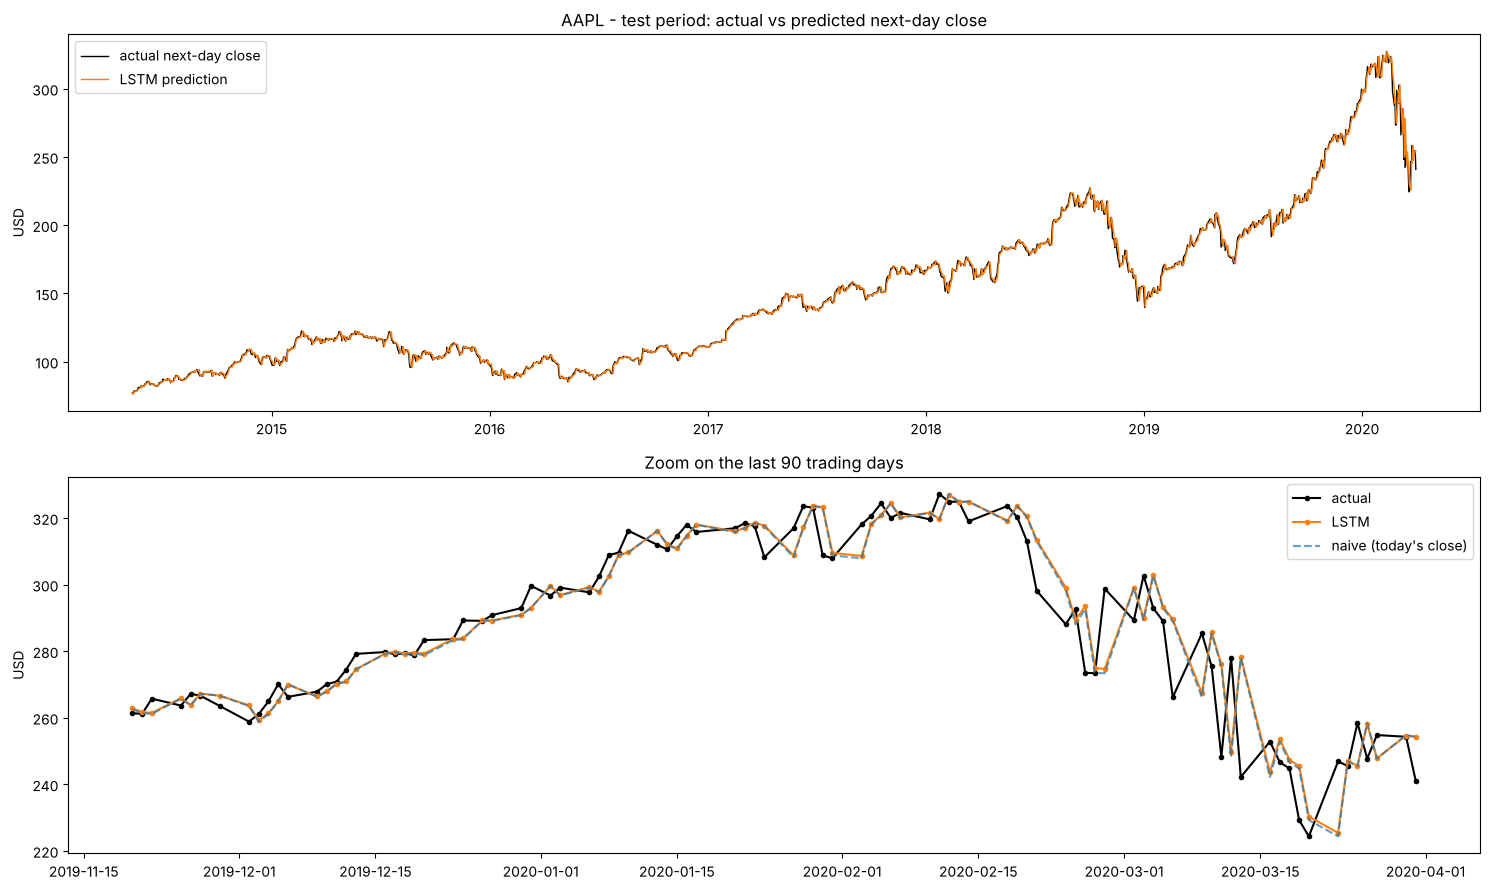

In [16]:
test_dates = dates[b:]
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
axes[0].plot(test_dates, true_price, label='actual next-day close', color='black', lw=1)
axes[0].plot(test_dates, preds['LSTM'], label='LSTM prediction', color='tab:orange', lw=1)
axes[0].set_title(f'{SYMBOL} - test period: actual vs predicted next-day close')
axes[0].set_ylabel('USD'); axes[0].legend()

zoom = slice(-90, None)
axes[1].plot(test_dates[zoom], true_price[zoom], 'o-', label='actual', color='black', ms=3)
axes[1].plot(test_dates[zoom], preds['LSTM'][zoom], 'o-', label='LSTM', color='tab:orange', ms=3)
axes[1].plot(test_dates[zoom], naive_price[zoom], '--', label='naive (today\'s close)', color='tab:blue', alpha=0.7)
axes[1].set_title('Zoom on the last 90 trading days')
axes[1].set_ylabel('USD'); axes[1].legend()
plt.tight_layout()
plt.show()

### Analysis of the results

| Model | R² (price) | MAE (USD) | R² (daily return) | Direction accuracy |
|---|---|---|---|---|
| LSTM | 0.9966 | 1.83 | 0.006 | 50.1% |
| GRU | 0.9966 | 1.84 | 0.002 | 50.0% |
| Naive baseline (tomorrow = today) | 0.9966 | 1.83 | −0.003 | – |

- **R² on the price = 0.9966**, as required by the instructions: the predicted next-day closes follow the actual curve almost perfectly over 2014–2020, with an average error of **\$1.83**.
- **But this score is misleading.** The naive baseline, which simply says "tomorrow's close = today's close", gets exactly the same R² (0.9966) and the same error. A stock price changes very little from one day to the next compared to its variations over 6 years (from \$76 to \$327), so *any* prediction close to today's price gets an R² near 1. The zoom on the last 90 days shows it: the LSTM curve is almost the naive curve, shifted by one day.
- The real question is whether the model predicts the **daily change**. On the next-day **returns**, the R² is about **0** (0.006 for the LSTM) and the direction (up or down) is right only **50% of the time**, like a coin flip (52.9% of the test days were up days). The LSTM and the GRU behave the same way: the GRU is slightly smaller but neither architecture finds a usable pattern.
- **Learning curves:** both models converge in 2–3 epochs, and early stopping ends the training after 9 epochs. The validation loss is *lower* than the training loss because the training period (1981–2008, including the dot-com bubble) was much more volatile in relative terms than the 2008–2014 validation period, and dropout is active during training only. There is nothing more to learn from the past prices: more epochs only make the model fit the noise of the training period.

**Conclusion:** the LSTM pipeline works (preprocessing, custom `Dataset`, `DataLoader`, LSTM/GRU with dropout and a dense layer, training/validation loops, early stopping, R² evaluation), and it gives a high R² on prices. However, it does **not** beat the naive forecast: daily stock returns are almost unpredictable from past prices alone, which is consistent with the efficient market hypothesis. This shows why a model should always be compared with a simple baseline, and why the R² on prices is not a good measure of a stock forecasting model (better: R² or accuracy on returns, or the profit of a trading strategy). Adding other information (news sentiment, market indices, fundamentals) would be needed to have a chance of doing better.

### Save the scaler (and the model) for future predictions

In [17]:
os.makedirs("artifacts", exist_ok=True)
joblib.dump({'x_scaler': x_scaler, 'y_scaler': y_scaler, 'window': WINDOW, 'features': FEATURES}, "artifacts/scalers.joblib")
torch.save(lstm_model.state_dict(), "artifacts/lstm_model.pt")
print("Saved:", os.listdir("artifacts"))

# Reload everything and predict tomorrow's close from the last 30 days of data
saved = joblib.load("artifacts/scalers.joblib")
reloaded = LSTMModel().to(device)
reloaded.load_state_dict(torch.load("artifacts/lstm_model.pt", map_location=device))
reloaded.eval()

last_window = data[FEATURES].values[-WINDOW:]
lc = last_window[-1, 3]
features = np.hstack([last_window[:, :4] / lc - 1, last_window[:, 4:5] / last_window[:, 4].mean()])
x = saved['x_scaler'].transform(features).reshape(1, WINDOW, len(FEATURES))
with torch.no_grad():
    ret = saved['y_scaler'].inverse_transform(reloaded(torch.tensor(x, dtype=torch.float32).to(device)).cpu().numpy().reshape(-1, 1))[0, 0]
print(f"Last close ({data.index[-1].date()}): {lc:.2f} USD -> predicted next close: {lc * (1 + ret):.2f} USD ({ret:+.2%})")

Saved: ['scalers.joblib', 'lstm_model.pt']
Last close (2020-03-31): 254.29 USD -> predicted next close: 254.21 USD (-0.03%)
